# 1 · Demand Patterns and Forecast Comparison

<a href="https://colab.research.google.com/github/FH-Prevail/jku_course/blob/main/notebooks/1_see_and_forecast.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

If the button does not open, use this link, or copy it into the browser: <a href="https://colab.research.google.com/github/FH-Prevail/jku_course/blob/main/notebooks/1_see_and_forecast.ipynb" target="_parent">https://colab.research.google.com/github/FH-Prevail/jku_course/blob/main/notebooks/1_see_and_forecast.ipynb</a>

Or in Colab: **File, Open notebook, GitHub**, type `FH-Prevail/jku_course` and choose the notebook.

*UE Digital Analytics im Handel · JKU Linz · 03.10.2026 · Sina Mirshahi, Logistikum*

Choose **Copy to Drive** (File, Save a copy in Drive), then **Runtime → Run all**. You do not have to write code: run the cells, read the outputs and use the controls.

Every cell shows its code above its result. The first cell loads the course data and the precomputed forecasts from the course repository, github.com/FH-Prevail/jku_course; it does not train a model, and it takes a few seconds.

**Ask Gemini about the code:** select a cell and ask, for example, “Explain this code line by line in plain English” or “Change this to show the Puzzle 1000 instead”. Read what it changed before you run it, and check its answer against the numbers. If Gemini is unavailable, ask a neighbour or the lecturer. Use only the synthetic course data.

**If a control is missing:** use the static example directly above it. If you edited a cell by accident, Undo, then run it again; otherwise reopen a fresh copy from the repository. Restarting does not undo edits.

## Your assignment (graded)

This notebook is **half of your T2 assignment**; notebook 2 is the other half. Together they count **25 % of the course grade**, plus 5 % for taking part in class. This notebook has **3 tasks and 10 points**.

- **Every task says step by step what to do** and shows a worked example for the Plush Bear in store. Do the same for your own product, with your own numbers.
- **Write your answers** in the cells marked **Your answer**: double-click the cell, replace each ___ with your answer, then press Shift + Enter.
- **Individual work.** You may discuss with others, but the answers you submit are your own.
- **Gemini is allowed.** Say in your answer where you used it, and check what it says against the numbers.
- **Submit by Saturday 10 October 2026, 23:59** in the T2 assignment on MS Teams: in Colab choose **File, Download, Download .ipynb**, name the file `T2_Notebook1_Lastname_Firstname.ipynb` and upload it.
- Run all cells before you download, so your results are saved next to your answers.

In [1]:
# Start here: run this cell first. It loads the course data from GitHub and prepares the pictures.
import json
import urllib.request
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from IPython.display import display

SOURCE = "https://raw.githubusercontent.com/FH-Prevail/jku_course/main/data/classroom"   # the course data on GitHub
demand = pd.read_csv(f"{SOURCE}/demand.csv", parse_dates=["week_start"])          # weekly sales: one row per product, channel and week
products = pd.read_csv(f"{SOURCE}/products.csv").set_index("product_id")           # price, cost and supplier lead time of each product
comparisons = pd.read_csv(f"{SOURCE}/comparisons.csv", parse_dates=["week_start", "test_start"])  # the backtest forecasts
inventory = pd.read_csv(f"{SOURCE}/inventory.csv", parse_dates=["week_start"])     # forecasts 1 to 7 weeks ahead, for the stock replay
results = json.load(urllib.request.urlopen(f"{SOURCE}/results.json"))             # numbers computed in advance

METHODS = ["Repeat last year", "Simple exponential smoothing", "Prophet", "LightGBM in global mode"]  # the four approaches
PRODUCTS = {"Plush Bear, store": "P010_store", "Plush Bear, online": "P010_online",   # name shown -> series in the data
            "Puzzle 1000, store": "P011_store", "Vacuum Filter, store": "P035_store",
            "Garden Hose, store": "P015_store"}
WINDOWS = {"Spring": "2025-03-24", "Summer": "2025-06-16", "Christmas": "2025-12-01"}   # first week of each 4-week test window
COLORS = {"Actual sales": "#262626", "Repeat last year": "#E66A1F", "Simple exponential smoothing": "#1B9E5A",
          "Prophet": "#D04F95", "LightGBM in global mode": "#0B5CAD"}                 # the same colour per method as on the slides
MARKERS = {"Repeat last year": "s", "Simple exponential smoothing": "^", "Prophet": "X", "LightGBM in global mode": "D"}
BLUE = "#0B5CAD"
plt.rcParams.update({"font.size": 12, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.alpha": 0.2, "figure.dpi": 110})


def series_id(product):
    """Turn a product name such as 'Plush Bear, store' into its series in the data, 'P010_store'."""
    if product in PRODUCTS:
        return PRODUCTS[product]
    if product in PRODUCTS.values():
        return product
    raise ValueError("Choose one of the product names in the dropdown.")


def neat(table, formats=None, na_rep=""):
    """Show a table the same way in every cell: all titles in one header row, the first column on the left,
    the other columns on the right, under their titles."""
    table = table.rename_axis(columns=None)          # no title above the column titles
    if table.index.name is not None:
        table = table.reset_index()                  # the row labels become an ordinary first column
    styled = table.style.hide(axis="index")
    if formats:
        styled = styled.format(formats, na_rep=na_rep)
    return styled.set_table_styles([
        {"selector": "th, td", "props": "text-align: right; padding: 4px 14px;"},
        {"selector": "th.col0, td.col0", "props": "text-align: left;"},
    ])

print("Ready. The course data is loaded.")
print("The forecasts were computed in advance, using only what was known at each forecast date.")


Ready. The course data is loaded.
The forecasts were computed in advance, using only what was known at each forecast date.


**Your name:** ___

**Student number:** ___

## 1. Read the demand

The retailer sells 40 products through two channels, store and online: 80 series of weekly sales. The data is synthetic, built to look like a real retailer's numbers.

Read the channel picture (slide 10). Is one channel growing? Do you see a recurring busy season?

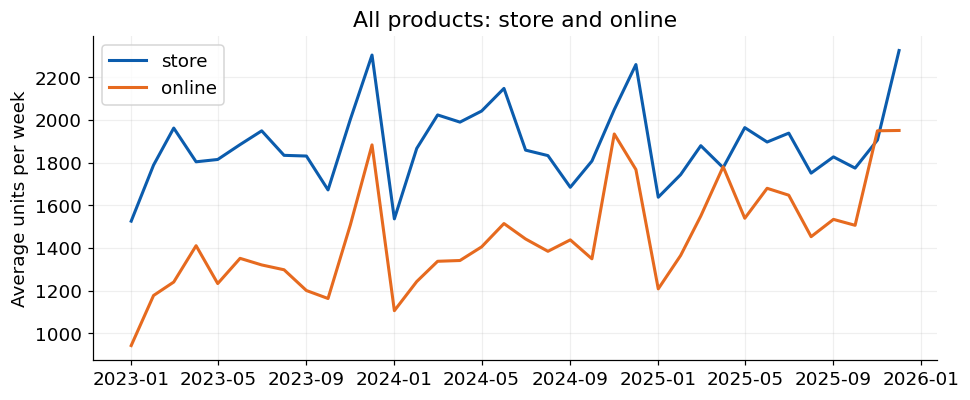

Year,"Store, units per week","Online, units per week"
2023,"1,855","1,300"
2024,"1,919","1,437"
2025,"1,868","1,596"


In [2]:
def totals():
    """Average units sold per week in each month, store and online, then the same average for each year (slide 10)."""
    weekly = demand.groupby(["week_start", "channel"])["units"].sum().unstack()      # one row per week: store and online
    monthly = weekly.resample("MS").mean()                      # average week of each month: months hold 4 or 5 weeks
    fig, ax = plt.subplots(figsize=(9, 3.8))
    ax.plot(monthly.index, monthly["store"], color=BLUE, lw=2, label="store")
    ax.plot(monthly.index, monthly["online"], color=COLORS["Repeat last year"], lw=2, label="online")
    ax.set(ylabel="Average units per week", title="All products: store and online")
    ax.legend()
    fig.tight_layout()
    plt.show()
    yearly = weekly.groupby(weekly.index.year).mean()           # average week of each year
    table = yearly.rename_axis("Year").rename(columns={"store": "Store, units per week", "online": "Online, units per week"})
    return neat(table[["Store, units per week", "Online, units per week"]], {"Store, units per week": "{:,.0f}", "Online, units per week": "{:,.0f}"})


totals()

**What to see.** Online sells more every year, from about 1,300 to 1,600 units a week; the store moves up and down. The picture shows the average week of each month, because months hold four or five weeks.

**The busy season** (slide 11). The seasonal index divides a month's average weekly sales by the category's average week over all three years: 1.00 is an average month, 2.00 twice as much.

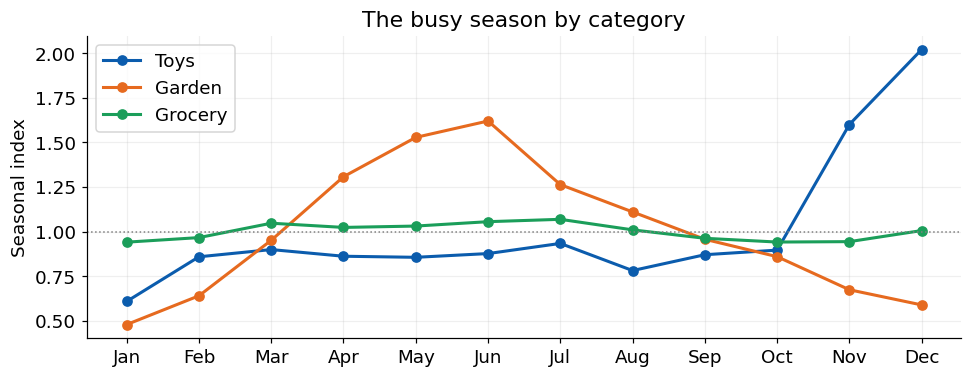

Category,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
Electronics,0.78,0.96,0.95,0.92,0.91,1.03,0.96,0.87,0.91,0.92,1.34,1.49
Fashion,0.82,1.01,1.14,1.13,0.82,0.90,0.82,1.07,1.14,0.96,1.16,1.07
Garden,0.48,0.64,0.95,1.31,1.53,1.62,1.26,1.11,0.96,0.86,0.67,0.59
Grocery,0.94,0.97,1.05,1.02,1.03,1.06,1.07,1.01,0.96,0.94,0.94,1.01
Spare Parts,0.73,0.84,1.31,0.82,0.86,0.77,1.31,1.17,1.07,1.03,0.86,1.20
Toys,0.61,0.86,0.90,0.86,0.86,0.88,0.93,0.78,0.87,0.90,1.60,2.02


In [3]:
def season_by_category(categories=("Toys", "Garden", "Grocery")):
    """The busy season (slide 11): a month's average weekly sales divided by the category's average weekly sales, 2023 to 2025.
    1.00 is the category's average month; 2.00 is twice as much."""
    x = demand.assign(month=demand["week_start"].dt.month)
    index = x.groupby(["category", "month"])["units"].mean() / x.groupby("category")["units"].mean()
    index = index.unstack()                                     # one row per category, one column per month
    months = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]
    fig, ax = plt.subplots(figsize=(9, 3.6))
    for colour, category in zip([BLUE, COLORS["Repeat last year"], COLORS["Simple exponential smoothing"]], categories):
        ax.plot(range(1, 13), index.loc[category], color=colour, lw=2, marker="o", label=category)
    ax.axhline(1, color="#808080", lw=1, ls=":")
    ax.set(xticks=range(1, 13), xticklabels=months, ylabel="Seasonal index", title="The busy season by category")
    ax.legend()
    fig.tight_layout()
    plt.show()
    index.columns = months
    return neat(index.rename_axis("Category"), {m: "{:.2f}" for m in months})


season_by_category()

**What to see.** Toys sell about twice their average month in December; Garden peaks in June and drops to half in January; Grocery hardly changes. A method that cannot see the calendar will be surprised every December.

**Promotions** (slide 12). Sales in a promotion week, divided by a normal week of the same product: no promotion that week or the week before. The left picture compares discounts; the right one follows the average promotion week by week.

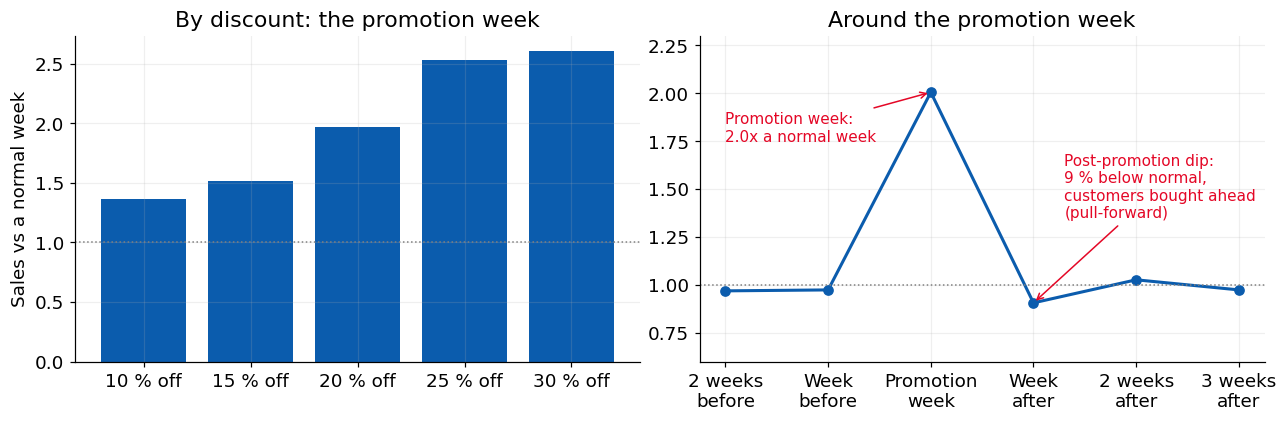

Online reacts more than the store: 2.10x against 1.91x.
The week after a promotion sells 9 percent below normal, the post-promotion dip: some customers bought ahead, during the promotion (pull-forward).


Discount,Sales vs a normal week
10 %,1.36x
15 %,1.51x
20 %,1.97x
25 %,2.53x
30 %,2.60x


In [4]:
def promotion_around():
    """The weeks around a promotion (slide 12), each against a normal week of the same product.
    Every promotion in the data lasts one week. Each position counts only weeks with no promotion in between:
    "Week after" is a week without a promotion that comes right after a promotion week."""
    x = demand.sort_values(["series_id", "week_start"]).copy()
    flag = x.groupby("series_id")["promo_flag"]
    later = {k: flag.shift(-k).fillna(0) == 1 for k in (1, 2)}               # a promotion k weeks later
    earlier = {k: flag.shift(k).fillna(0) == 1 for k in (1, 2, 3)}           # a promotion k weeks earlier
    none = x["promo_flag"] == 0
    with_promotions = flag.transform("sum") > 0                               # products that had at least one promotion
    normal = x[with_promotions & none & ~earlier[1]].groupby("series_id")["units"].mean()
    x["vs_normal"] = x["units"] / x["series_id"].map(normal)                  # 1.00 = a normal week of that product
    weeks = {"2 weeks before": none & ~later[1] & later[2],
             "Week before": none & later[1],
             "Promotion week": x["promo_flag"] == 1,
             "Week after": none & earlier[1],
             "2 weeks after": none & ~earlier[1] & earlier[2],
             "3 weeks after": none & ~earlier[1] & ~earlier[2] & earlier[3]}
    return pd.Series({name: x.loc[rows, "vs_normal"].mean() for name, rows in weeks.items()})


def promotion_lift():
    """Promotion effects (slide 12): sales in a promotion week divided by a normal week of the same product, by discount,
    then the weeks around a promotion. A normal week has no promotion this week and none the week before."""
    x = demand.sort_values(["series_id", "week_start"]).copy()
    x["promo_last_week"] = x.groupby("series_id")["promo_flag"].shift(1).fillna(0)
    x = x[x.groupby("series_id")["promo_flag"].transform("sum") > 0]           # products that had at least one promotion
    normal = x[(x["promo_flag"] == 0) & (x["promo_last_week"] == 0)].groupby("series_id")["units"].mean()
    x["vs_normal"] = x["units"] / x["series_id"].map(normal)                    # 1.00 = a normal week of that product
    promo = x[x["promo_flag"] == 1]
    by_discount = promo.groupby("discount_pct")["vs_normal"].mean()
    around = promotion_around()
    dip = (1 - around["Week after"]) * 100                                      # percent below a normal week
    red = "#E40726"                                                             # FH red, only for the two pointers
    fig, (left, right) = plt.subplots(1, 2, figsize=(12, 4))
    left.bar([f"{d:.0f} % off" for d in by_discount.index], by_discount.values, color=BLUE)
    left.axhline(1, color="#808080", lw=1, ls=":")
    left.set(ylabel="Sales vs a normal week", title="By discount: the promotion week")
    right.plot(range(len(around)), around.values, color=BLUE, marker="o", lw=2)
    right.axhline(1, color="#808080", lw=1, ls=":")
    right.set(xticks=range(len(around)), xticklabels=["\n".join(name.rsplit(" ", 1)) for name in around.index],
              ylim=(0.6, 2.3), title="Around the promotion week")
    right.annotate(f"Promotion week:\n{around['Promotion week']:.1f}x a normal week", xy=(2, around["Promotion week"]),
                   xytext=(0, 1.75), fontsize=10, color=red, arrowprops=dict(arrowstyle="->", color=red))
    right.annotate(f"Post-promotion dip:\n{dip:.0f} % below normal,\ncustomers bought ahead\n(pull-forward)", xy=(3, around["Week after"]),
                   xytext=(3.3, 1.35), fontsize=10, color=red, arrowprops=dict(arrowstyle="->", color=red))
    fig.tight_layout()
    plt.show()
    by_channel = promo.groupby("channel")["vs_normal"].mean()
    print(f"Online reacts more than the store: {by_channel['online']:.2f}x against {by_channel['store']:.2f}x.")
    print(f"The week after a promotion sells {dip:.0f} percent below normal, the post-promotion dip: "
          "some customers bought ahead, during the promotion (pull-forward).")
    table = pd.DataFrame({"Discount": [f"{d:.0f} %" for d in by_discount.index], "Sales vs a normal week": [f"{v:.2f}x" for v in by_discount.values]})
    return neat(table)


promotion_lift()

**What to see.** A deeper discount sells more. The promotion week sells about twice a normal week, and the week after sells less than normal: the **post-promotion dip**. Some customers bought ahead during the promotion (pull-forward), so part of the extra sales only moved forward. Promotions are planned, so a forecast can know about them in advance.

Four demand patterns are useful descriptions, not guarantees of forecast accuracy: **smooth** means regular sales and fairly regular amounts; **erratic** means frequent sales with variable amounts; **intermittent** means many weeks without sales; **lumpy** adds variable amounts to those gaps.

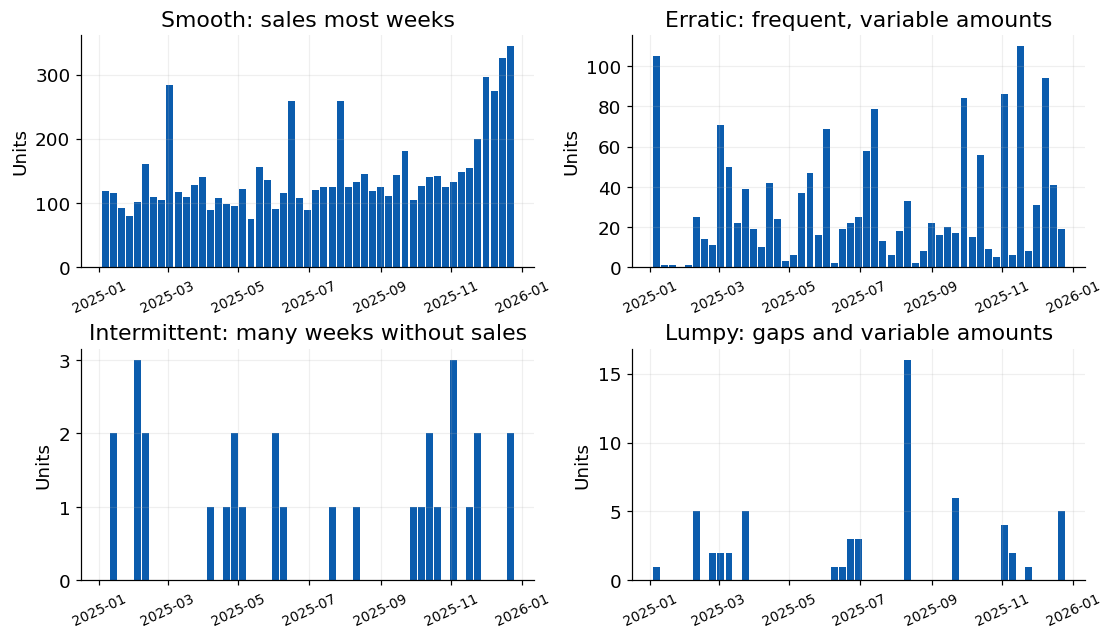

In [5]:
def pattern_examples():
    """One product of each demand pattern: its weekly sales in 2025."""
    examples = [("P010_store", "Smooth: sales most weeks"),
                ("P011_store", "Erratic: frequent, variable amounts"),
                ("P035_store", "Intermittent: many weeks without sales"),
                ("P038_store", "Lumpy: gaps and variable amounts")]
    fig, axes = plt.subplots(2, 2, figsize=(10, 5.7), layout="constrained")
    for ax, (sid, title) in zip(axes.flat, examples):
        sales = demand[(demand["series_id"] == sid) & (demand["week_start"].dt.year == 2025)]
        ax.bar(sales["week_start"], sales["units"], width=6, color=BLUE)
        ax.set(title=title, ylabel="Units")
        ax.tick_params(axis="x", rotation=25, labelsize=9)
    plt.show()


pattern_examples()

Two numbers place every product on one picture. **ADI** (average demand interval) is the average number of weeks between sales: 1 means a sale every week. **CV²** (squared coefficient of variation) says how irregular the amounts are from one sale to the next. The dashed lines are the usual limits from the literature, 1.32 and 0.49; they are a convention, not a law.

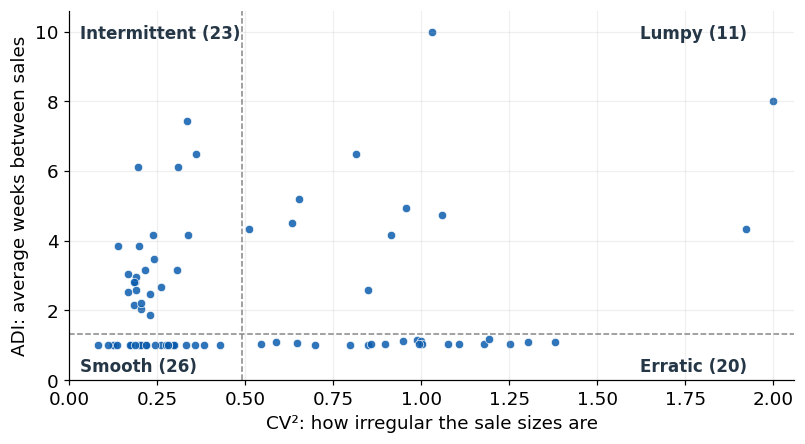

Each dot is one product in one channel, classified on 2023 and 2024. Values beyond the edge are drawn on the edge.
ADI: the average number of weeks between sales (1 = a sale every week). CV²: how irregular the amounts are from one sale to the next.


In [6]:
def pattern_map():
    """Every series placed by its two numbers, ADI and CV²: the four demand patterns as one picture."""
    series = pd.DataFrame(results["patterns"]["series"])
    cuts, counts = results["patterns"]["cuts"], results["patterns"]["counts"]
    fig, ax = plt.subplots(figsize=(7.5, 4.2))
    ax.scatter(series["cv2"].clip(upper=2), series["adi"].clip(upper=10), color=BLUE, s=30, alpha=0.85, edgecolor="white", lw=0.5)
    ax.axvline(cuts["cv2"], color="#888888", ls="--", lw=1)     # the usual limits from the literature
    ax.axhline(cuts["adi"], color="#888888", ls="--", lw=1)
    ax.set(xlabel="CV²: how irregular the sale sizes are", ylabel="ADI: average weeks between sales", xlim=(0, 2.06), ylim=(0, 10.6))
    for name, x, y in [("Smooth", 0.03, 0.25), ("Erratic", 1.62, 0.25), ("Intermittent", 0.03, 9.8), ("Lumpy", 1.62, 9.8)]:
        ax.text(x, y, f"{name} ({counts[name.lower()]})", fontsize=11, color="#253746", weight="bold")
    fig.tight_layout()
    plt.show()
    print("Each dot is one product in one channel, classified on 2023 and 2024. Values beyond the edge are drawn on the edge.")
    print("ADI: the average number of weeks between sales (1 = a sale every week). CV²: how irregular the amounts are from one sale to the next.")


pattern_map()

### Task 1.1 · Your product's demand pattern (2 points)

**Choose your product** for this notebook, one of these three: `Plush Bear, online` · `Puzzle 1000, store` · `Garden Hose, store`. You use the same product in all three tasks. The Plush Bear in store is the worked example, so it is not one of the choices.

**What to do**
1. In the cell below, replace `Plush Bear, store` with the name of your product. Keep the quotation marks.
2. Run the cell. It prints two numbers, ADI and CV², and the demand pattern.
3. Copy them into the answer cell and complete the two sentences. Rule of thumb: an ADI close to 1 means a sale every week, above 1.32 many weeks without a sale; a CV² below 0.49 means fairly regular amounts, above 0.49 very variable amounts.

**Worked example, Plush Bear in store:** ADI 1.00, so it sells every week; CV² 0.30, below 0.49, so the amounts are fairly regular; demand pattern: smooth.

In [7]:
def pattern_of(product="Plush Bear, store"):
    """The two numbers of one product, ADI and CV², and the demand pattern they give (measured on 2023 and 2024)."""
    sid = series_id(product)
    row = next(s for s in results["patterns"]["series"] if s["series_id"] == sid)
    cuts = results["patterns"]["cuts"]
    print(f"{product}: ADI {row['adi']:.2f} (limit {cuts['adi']}), CV² {row['cv2']:.2f} (limit {cuts['cv2']})")
    print(f"Demand pattern: {row['pattern']}")


pattern_of("Plush Bear, store")   # put the name of your product here

Plush Bear, store: ADI 1.00 (limit 1.32), CV² 0.30 (limit 0.49)
Demand pattern: smooth


**Your answer, Task 1.1**

- My product: ___
- ADI: ___, so the product sells ___ (every week, or with many weeks without a sale)
- CV²: ___, so the amounts are ___ (fairly regular, or very variable)
- Demand pattern: ___ (smooth, erratic, intermittent or lumpy)

## 2. Compare four approaches

- **Repeat last year**, also called seasonal naive: reuse sales from 52 weeks earlier.
- **Simple exponential smoothing (SES)**: a weighted average that gives more weight to recent sales; it forecasts one constant level for all weeks ahead.
- **Prophet**, a local model from Meta: one model per product and channel that adds up a trend, a yearly season and the effect of the planned discount.
- **LightGBM in global mode**: one LightGBM model learns from all products and channels, using past sales and planned prices, promotions and calendar information. (LightGBM can also be trained one series at a time, in local mode; here it runs in global mode.)

We forecast the same four weeks with each method and then reveal actual sales. An **average miss** is the average absolute difference in units. **Total miss as a percentage of demand** adds up those absolute misses and divides by total actual demand. **Bias** is the average forecast minus actual: positive means too high, negative means too low.

First look at the Christmas example. Do not choose a winner from the shape alone; read its errors too.

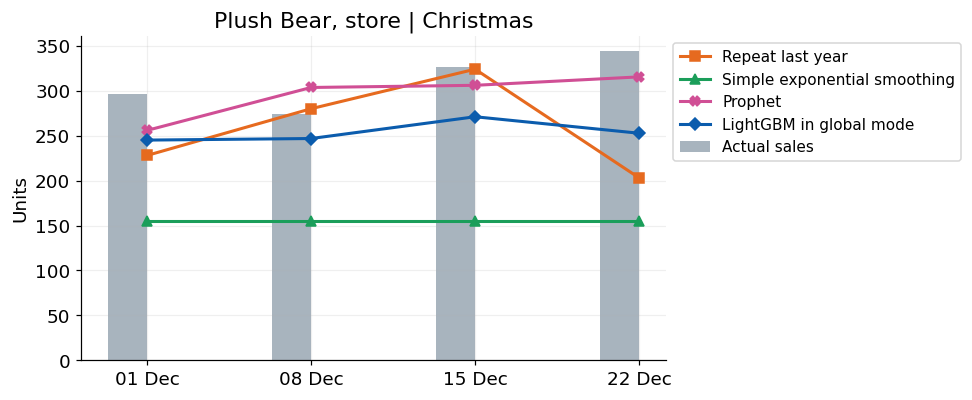

Forecast made after 2025-11-24; all four weeks forecast together.


Method,"Average miss, units","Total miss, % of demand","Average bias, units"
Repeat last year,54.2,17.5 %,-51.2
Simple exponential smoothing,154.9,50.0 %,-154.9
Prophet,29.6,9.5 %,-14.7
LightGBM in global mode,56.1,18.1 %,-56.1


In this window, Prophet has the smallest average miss. This is evidence for this product and window only.
Bias is forecast minus actual: positive means too high; negative means too low.


In [8]:
def comparison_data(product="Plush Bear, store", window="Christmas"):
    """The four forecasts and the actual sales for one product and one 4-week test window."""
    if window not in WINDOWS:
        raise ValueError("Choose Spring, Summer or Christmas.")
    rows = comparisons[(comparisons["series_id"] == series_id(product)) &
                       (comparisons["test_start"] == pd.Timestamp(WINDOWS[window]))]
    return rows.copy()


def score_table(rows):
    """For each method: average miss in units, total miss as a share of demand, and average bias (forecast minus actual)."""
    table = []
    for method in METHODS:
        scored = rows[(rows["method"] == method) & (rows["scoreable"] == 1)]   # weeks with an empty shelf are left out
        actual = scored["actual"].to_numpy()
        forecast = scored["forecast"].to_numpy()
        total = actual.sum()
        table.append({"Method": method,
                      "Average miss, units": np.abs(forecast - actual).mean(),
                      "Total miss, % of demand": np.abs(forecast - actual).sum() / total * 100 if total else np.nan,
                      "Average bias, units": (forecast - actual).mean()})
    return pd.DataFrame(table).set_index("Method")


def compare(product="Plush Bear, store", window="Christmas"):
    """Chart the four forecasts against actual sales, then score them."""
    rows = comparison_data(product, window)
    actual = rows[rows["method"] == METHODS[0]].sort_values("week_start")
    fig, ax = plt.subplots(figsize=(9, 3.8))
    ax.bar(np.arange(4) - 0.12, actual["actual"], width=0.24, color="#A8B4BE", label="Actual sales")
    for method in METHODS:
        forecast = rows[rows["method"] == method].sort_values("week_start")
        ax.plot(range(4), forecast["forecast"], color=COLORS[method], marker=MARKERS[method], lw=2, label=method)
    ax.set(xticks=range(4), xticklabels=actual["week_start"].dt.strftime("%d %b"), ylabel="Units", title=f"{product} | {window}")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=10)
    fig.tight_layout()
    plt.show()
    made = (actual["week_start"].min() - pd.Timedelta(weeks=1)).date()
    print(f"Forecast made after {made}; all four weeks forecast together.")
    scores = score_table(rows)
    display(neat(scores, {"Average miss, units": "{:.1f}", "Total miss, % of demand": "{:.1f} %",
                          "Average bias, units": "{:+.1f}"}, na_rep="Undefined: no demand"))
    winner = scores["Average miss, units"].idxmin()
    print(f"In this window, {winner} has the smallest average miss. This is evidence for this product and window only.")
    print("Bias is forecast minus actual: positive means too high; negative means too low.")


compare('Plush Bear, store', 'Christmas')

**What to see.** The printed sentence names the method with the smallest miss in this window. The bias column adds direction; the same method need not win in another season or for another product.

**Try it using the dropdowns.** Change Window to Summer. Then select Garden Hose, store. Compare that product in Summer and Christmas. Change Plush Bear from store to online to investigate a channel difference.

In [ ]:
def forecast_widget():
    """Two dropdowns, product and window, that redraw the comparison."""
    from ipywidgets import interactive, Dropdown
    controls = interactive(compare,
                           product=Dropdown(options=list(PRODUCTS), value="Plush Bear, store", description="Product"),
                           window=Dropdown(options=list(WINDOWS), value="Christmas", description="Window"))
    display(controls)
    return controls


forecast_controls = forecast_widget()

### Task 1.2 · Two windows compared (4 points)

**What to do**
1. In the dropdowns above, choose **your product** and the window **Christmas**. No dropdowns? Type `compare("Garden Hose, store", "Christmas")` with your product into the empty code cell under this task and run it.
2. Look at the table under the chart. Find the **smallest number in the column "Average miss, units"**; the sentence under the table names that method too.
3. Write down that method, its average miss and its **average bias with its sign**: + means the forecast was too high, − too low.
4. Change the window to **Summer** and do the same.
5. Answer the two questions under the table. For the second one, choose the reason that fits your table best:
   - **A.** Christmas has a peak (see the busy season in section 1). Methods that see the yearly season (repeat last year, Prophet, LightGBM in global mode) can follow it; simple exponential smoothing draws one flat line.
   - **B.** Only Prophet and LightGBM in global mode know the planned discounts (see the promotion effects in section 1).
   - **C.** Last year's season can mislead: when this year's peak is smaller or larger, the methods that copy last year miss.
   - **D.** LightGBM in global mode learns from all 80 series at once, so it does well for many products.

**Worked example, Plush Bear in store:** at Christmas **Prophet** has the smallest average miss, **29.6** units, with a bias of **-14.7**. In Summer it is **LightGBM in global mode**, **13.7** units, bias **+9.1**. Not the same method. Reason A: simple exponential smoothing drew one flat line and missed the Christmas weeks by 154.9 units on average.

**Your answer, Task 1.2**

| Window | Method with the smallest average miss | Its average miss, units | Its average bias, units, with + or − |
|---|---|---|---|
| Christmas | ___ | ___ | ___ |
| Summer | ___ | ___ | ___ |

- Is it the same method in both windows? ___ (yes or no)
- The reason that fits my table best: ___ (A, B, C or D), because ___ (one sentence with your numbers)

**Optional, not graded: change the code with Gemini.** Ask Gemini to write the code that shows your product in Spring, for example: *"Use compare to show Garden Hose, store in Spring"*, and run it in the empty cell below. No Gemini on your account? Copy the last line of the cell in section 2 into the empty cell and change the product and the window.

In [10]:
# Optional: the code from Gemini, or your own, goes here


## 3. Your first recommendation

### Task 1.3 · Your forecast choice (4 points)

Imagine the store manager asks you: *"Which forecast should we use for this product?"* Answer in five short lines.

**What to do**
1. Choose **one window** from your Task 1.2 table: Christmas or Summer.
2. **Recommend a method**, usually the one with the smallest average miss. Another one is fine if you say why.
3. **Give your evidence:** its average miss from your table, and the average miss of repeat last year in the same window (the row "Repeat last year" in the table under the chart). If your method is repeat last year, compare it with the second best method instead.
4. **Name one risk** of trusting this evidence, and explain it in one sentence with your numbers:
   - **a.** It is only one window of four weeks.
   - **b.** The bias shows that the method runs too high or too low.
   - **c.** It is one product in one channel.
5. **Name one check** before ordering, and say why:
   - **a.** The whole-year table in section 4, after the break.
   - **b.** The same product in the other channel.
   - **c.** What running out costs compared with leftover stock.

**Worked example, Plush Bear in store:** (1) Christmas. (2) Prophet. (3) Its average miss was 29.6 units a week, against 54.2 for repeat last year. (4) Risk b: its bias was -14.7, so it ran about 15 units a week too low and the shelf could run empty. (5) Check a: over the whole year, LightGBM in global mode has the lowest WAPE (25.1 % against 27.1 % for Prophet), so the Christmas result may not hold in other weeks.

**Your answer, Task 1.3**

1. Window: ___
2. Method I recommend: ___
3. My evidence: its average miss was ___ units a week, against ___ units for ___.
4. Risk (a, b or c): ___, because ___
5. Check (a, b or c): ___, because ___

Stop here for the first exercise. The following sections support the evaluation discussion after the break.

## 4. Check more than one window

A **backtest** replays past forecast decisions using only information available then. Here every method is tested at 13 dates, predicting the next four weeks each time; the test weeks run from 30 December 2024 to 22 December 2025.

**WAPE**, weighted absolute percentage error, is total absolute miss divided by total actual demand. **Percentage bias** is total signed error divided by total demand; earlier we expressed bias in units instead. Both definitions use forecast minus actual for the sign.

In [11]:
def backtest():
    """The backtest over 2025: total miss and bias of every method, all 80 series, 13 test dates."""
    table = []
    for method in METHODS:
        scored = comparisons[(comparisons["method"] == method) & (comparisons["scoreable"] == 1)]
        error = scored["forecast"] - scored["actual"]
        table.append([method, f"{error.abs().sum() / scored['actual'].sum() * 100:.1f} %",
                      f"{error.sum() / scored['actual'].sum() * 100:+.1f} %"])
    for method in ["Holt-Winters", "Croston SBA", "TSB", "Moving average"]:     # four more local methods, scored the same way
        score = results["backtest_all"][method]["all"]
        table.append([method, f"{score['wape']:.1f} %", f"{score['bias_pct']:+.1f} %"])
    print("13 test dates; four weeks ahead each; all 80 series. The same weeks and products for every method.")
    print("The four methods of the window comparison come first; four more local methods from the slides were scored the same way.")
    print("Flagged stock-out weeks are left out of the scoring because their demand is unknown.")
    return neat(pd.DataFrame(table, columns=["Method", "WAPE: total miss / total demand", "Bias: net error / total demand"]))


backtest()

13 test dates; four weeks ahead each; all 80 series. The same weeks and products for every method.
The four methods of the window comparison come first; four more local methods from the slides were scored the same way.
Flagged stock-out weeks are left out of the scoring because their demand is unknown.


Method,WAPE: total miss / total demand,Bias: net error / total demand
Repeat last year,43.8 %,-2.7 %
Simple exponential smoothing,34.9 %,-0.9 %
Prophet,27.1 %,+0.3 %
LightGBM in global mode,25.1 %,-3.1 %
Holt-Winters,39.0 %,-1.0 %
Croston SBA,34.9 %,-4.9 %
TSB,36.1 %,+0.0 %
Moving average,37.5 %,+0.2 %


**What to see.** The table compares all 80 series on the same dates; the four extra rows are the further local methods from the slides (Holt-Winters, Croston SBA, TSB, a moving average), scored the same way. Large sellers have more influence on these aggregate percentages, so the best assortment result does not promise the best result for your product. These results were computed in advance; LightGBM in global mode was retrained at each test date.

## 5. A forecast can be right most weeks and still miss all sales

**MAPE**, mean absolute percentage error, computes a percentage miss for each week before averaging. A week with zero actual demand makes that division undefined.

In [12]:
def zeros_demo():
    """A forecast of zero for a slow mover: right in three weeks, and still every unit missed."""
    actual = np.array([0, 0, 0, 4])
    forecast = np.zeros(4)
    print("Teaching example, not an extracted course product.")
    display(neat(pd.DataFrame({"Week": [1, 2, 3, 4], "Actual units": actual, "Forecast units": forecast}),
                 {"Actual units": "{:.0f}", "Forecast units": "{:.0f}"}))
    print("Three weeks exactly right, but all four units of demand missed.")
    print("MAPE is undefined because actual demand is zero in three weeks. WAPE is 100 %.")
    print("Do not choose a stock policy by counting the weeks a forecast gets right.")


zeros_demo()

Teaching example, not an extracted course product.


Week,Actual units,Forecast units
1,0,0
2,0,0
3,0,0
4,4,0


Three weeks exactly right, but all four units of demand missed.
MAPE is undefined because actual demand is zero in three weeks. WAPE is 100 %.
Do not choose a stock policy by counting the weeks a forecast gets right.


**What to see.** The zero forecast matches three weeks exactly but misses the only sale. Counting correct weeks is not enough to judge an order policy; carry this question into notebook 2: how much stock would you need?

**Evidence note.** Four observations in the source data are flagged as censored sales: the shelf was empty, so demand is unknown. For training, these are replaced with the preceding four weeks’ mean using only past information; flagged test rows are excluded from forecast scoring. The README of the `data` folder in the course repository describes the data in full.

## Before you submit

1. **Runtime, Run all**, so every result is saved next to your answers.
2. Check that every **Your answer** cell is filled in: no ___ left.
3. **File, Download, Download .ipynb**. Name the file `T2_Notebook1_Lastname_Firstname.ipynb`.
4. Upload it to the T2 assignment on MS Teams by **Saturday 10 October 2026, 23:59**.

## Extra, not graded: train a forecast yourself

If you are interested in how a forecast is made. Everything above used forecasts computed in advance; the two cells below train a model right here, in a few seconds each. Change the product or the forecast date in the last line of a cell: use a Monday from 30 December 2024 to 1 December 2025. On the 13 backtest dates (every four weeks from 30 December 2024, for example 1 December 2025) the table also shows the course forecast stored for the slides. If Colab reports a missing package, run `%pip install prophet` or `%pip install lightgbm` in a new cell.

**Prophet**, a local model: one model for one product and channel. It adds up a trend, a yearly season and the effect of the planned discount, with the same settings as the course model.

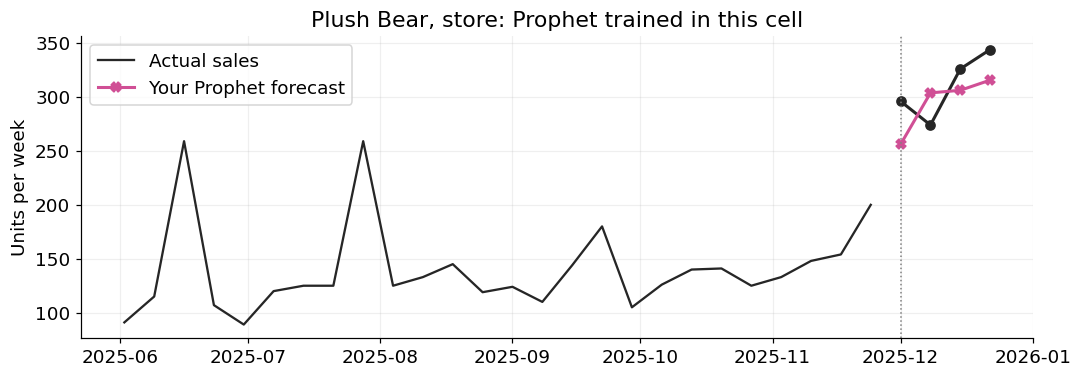

Average miss of your forecast: 29.5 units a week.


Week,Actual,Your forecast,Course forecast
01 Dec 2025,296,256,256
08 Dec 2025,274,304,304
15 Dec 2025,326,306,306
22 Dec 2025,344,316,315


In [13]:
def train_prophet(product="Plush Bear, store", forecast_date="2025-12-01"):
    """Extra, not graded: train Prophet yourself on one product and forecast the four weeks from the forecast date.
    The same settings as the course model: a trend, a yearly season and the planned discount, added together."""
    import logging
    for name in ("cmdstanpy", "prophet", "prophet.plot"):
        logging.getLogger(name).disabled = True                          # hide Prophet's progress messages
    try:
        from prophet import Prophet
    except ImportError:
        print("Prophet is not installed here. Run  %pip install prophet  in a new cell, then run this cell again.")
        return None
    start = pd.Timestamp(forecast_date)
    sales = demand[demand["series_id"] == series_id(product)].sort_values("week_start")
    past = sales[sales["week_start"] < start]                            # only what was known on the forecast date
    future = sales[sales["week_start"] >= start].head(4)                 # the four weeks we forecast
    model = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, uncertainty_samples=0)
    model.add_regressor("discount")                                      # the planned discount, known in advance
    model.fit(pd.DataFrame({"ds": past["week_start"], "y": past["units"], "discount": past["discount_pct"]}))
    plan = pd.DataFrame({"ds": future["week_start"], "discount": future["discount_pct"]})
    forecast = model.predict(plan)["yhat"].clip(lower=0).to_numpy()     # no negative sales
    fig, ax = plt.subplots(figsize=(10, 3.6))
    shown = past.tail(26)
    ax.plot(shown["week_start"], shown["units"], color=COLORS["Actual sales"], lw=1.5, label="Actual sales")
    ax.plot(future["week_start"], future["units"], color=COLORS["Actual sales"], marker="o", lw=2)
    ax.plot(future["week_start"], forecast, color=COLORS["Prophet"], marker=MARKERS["Prophet"], lw=2, label="Your Prophet forecast")
    ax.axvline(start, color="#808080", lw=1, ls=":")                    # the forecast date
    ax.set(ylabel="Units per week", title=f"{product}: Prophet trained in this cell")
    ax.legend()
    fig.tight_layout()
    plt.show()
    stored = comparisons[(comparisons["series_id"] == series_id(product)) & (comparisons["method"] == "Prophet")
                         & (comparisons["test_start"] == start)].sort_values("horizon")["forecast"].to_numpy()
    table = pd.DataFrame({"Week": future["week_start"].dt.strftime("%d %b %Y").to_list(), "Actual": future["units"].to_list(),
                          "Your forecast": forecast})
    if len(stored) == len(table):
        table["Course forecast"] = stored                                # the forecast stored for the slides
    print(f"Average miss of your forecast: {np.abs(forecast - future['units'].to_numpy()).mean():.1f} units a week.")
    return neat(table, {c: "{:.0f}" for c in table.columns if "forecast" in c})


train_prophet('Plush Bear, store', '2025-12-01')

**LightGBM in global mode**: one model learns from all 80 series at once. Each row is one series, one target week and how many weeks ahead (1 to 4); its inputs are only what was known on the forecast date: the last weeks' sales, the same week last year, the week of the year, the planned discount, and which product and channel it is. This is a smaller version of the course model (11 inputs instead of 26, no tuning), so its forecast differs a little from the stored one.

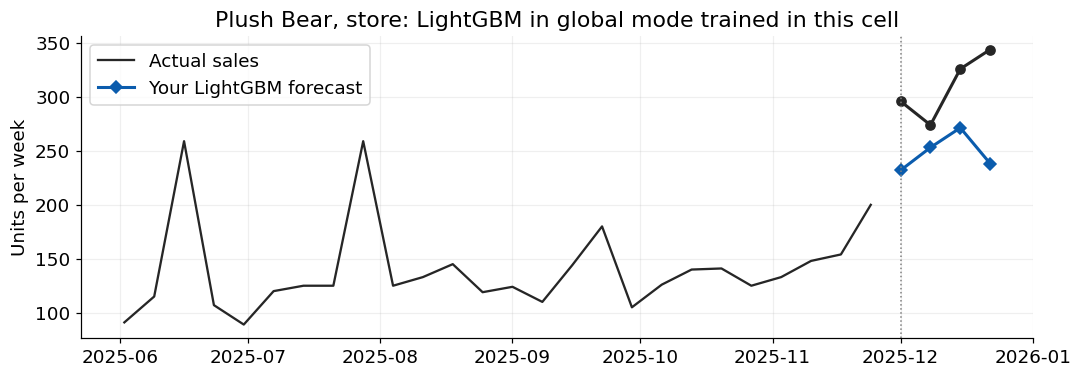

Trained on 32,000 rows from all 80 series. Average miss of your forecast: 61.3 units a week.


Week,Actual,Your forecast,Course forecast
01 Dec 2025,296,232,245
08 Dec 2025,274,253,247
15 Dec 2025,326,271,271
22 Dec 2025,344,238,253


In [14]:
def train_lightgbm(product="Plush Bear, store", forecast_date="2025-12-01"):
    """Extra, not graded: train LightGBM in global mode yourself, one model for all 80 series, then forecast one product
    for the four weeks from the forecast date. A smaller version of the course model: 11 inputs instead of 26, no tuning."""
    try:
        import lightgbm as lgb
    except ImportError:
        print("LightGBM is not installed here. Run  %pip install lightgbm  in a new cell, then run this cell again.")
        return None
    start = pd.Timestamp(forecast_date)
    d = demand.sort_values(["series_id", "week_start"]).reset_index(drop=True)
    sales = d.groupby("series_id")["units"]
    tables = []
    for ahead in range(1, 5):                                            # one row per series, target week and weeks ahead
        x = d[["series_id", "week_start", "units", "product_id", "channel", "discount_pct"]].copy()
        x["weeks_ahead"] = ahead
        for k in (1, 2, 3, 4):                                           # the last four weeks known on the forecast date
            x[f"sales_{k}_weeks_before"] = sales.shift(ahead + k - 1)
        x["average_last_8_weeks"] = sales.transform(lambda s: s.shift(ahead).rolling(8).mean())
        x["same_week_last_year"] = sales.shift(52)
        x["week_of_year"] = d["week_start"].dt.isocalendar().week.astype(int)
        tables.append(x)
    rows = pd.concat(tables).dropna()
    for column in ("product_id", "channel"):
        rows[column] = rows[column].astype("category")                   # one learned effect per product and channel
    inputs = [c for c in rows.columns if c not in ("series_id", "week_start", "units")]
    train = rows[rows["week_start"] < start]                             # only target weeks before the forecast date
    model = lgb.LGBMRegressor(objective="tweedie", n_estimators=300, learning_rate=0.05, num_leaves=31, verbose=-1)
    model.fit(train[inputs], train["units"])
    weeks = sorted(d.loc[d["week_start"] >= start, "week_start"].unique())[:4]
    test = rows[(rows["series_id"] == series_id(product)) & rows["week_start"].isin(weeks)]
    test = test[test["weeks_ahead"] == test["week_start"].map({w: i + 1 for i, w in enumerate(weeks)})].sort_values("week_start")
    forecast = model.predict(test[inputs])
    past = d[(d["series_id"] == series_id(product)) & (d["week_start"] < start)].tail(26)
    fig, ax = plt.subplots(figsize=(10, 3.6))
    ax.plot(past["week_start"], past["units"], color=COLORS["Actual sales"], lw=1.5, label="Actual sales")
    ax.plot(test["week_start"], test["units"], color=COLORS["Actual sales"], marker="o", lw=2)
    ax.plot(test["week_start"], forecast, color=COLORS["LightGBM in global mode"], marker=MARKERS["LightGBM in global mode"],
            lw=2, label="Your LightGBM forecast")
    ax.axvline(start, color="#808080", lw=1, ls=":")                    # the forecast date
    ax.set(ylabel="Units per week", title=f"{product}: LightGBM in global mode trained in this cell")
    ax.legend()
    fig.tight_layout()
    plt.show()
    stored = comparisons[(comparisons["series_id"] == series_id(product)) & (comparisons["method"] == "LightGBM in global mode")
                         & (comparisons["test_start"] == start)].sort_values("horizon")["forecast"].to_numpy()
    table = pd.DataFrame({"Week": test["week_start"].dt.strftime("%d %b %Y").to_list(), "Actual": test["units"].astype(int).to_list(),
                          "Your forecast": forecast})
    if len(stored) == len(table):
        table["Course forecast"] = stored                                # the forecast stored for the slides
    print(f"Trained on {len(train):,} rows from all {d['series_id'].nunique()} series. "
          f"Average miss of your forecast: {np.abs(forecast - test['units'].to_numpy()).mean():.1f} units a week.")
    return neat(table, {c: "{:.0f}" for c in table.columns if "forecast" in c})


train_lightgbm('Plush Bear, store', '2025-12-01')

**What to see.** Your Prophet forecast matches the course forecast almost exactly: the same model, the same data, the same settings. Your LightGBM forecast is close but not equal, because it has fewer inputs. Try asking Gemini to add one input, for example the average of the last 26 weeks, and compare the average miss.